In [1]:
'''#step0.0 logging all runs
import os
import sys
import logging
from datetime import datetime

# ADDED: Define your logs folder (adjust path as needed)
LOGS_DIR = "/home/maryam_s/Documents/GPU SAM/segment_anything/logs"
os.makedirs(LOGS_DIR, exist_ok=True)

# ADDED: Create a timestamp for the current run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_file = os.path.join(LOGS_DIR, f"experiment_log_{timestamp}.log")

# ADDED: Get the root logger and clear existing handlers
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)  # Capture all messages to file

# Remove any existing handlers
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

# ADDED: Create FileHandler for all messages (DEBUG and above)
file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.DEBUG)
file_formatter = logging.Formatter('%(asctime)s %(levelname)s: %(message)s')
file_handler.setFormatter(file_formatter)
logger.addHandler(file_handler)

# ADDED: Create a ConsoleHandler that shows INFO and above
# (This one uses sys.__stdout__ so it writes directly to the console)
console_handler = logging.StreamHandler(sys.__stdout__)
console_handler.setLevel(logging.INFO)
console_formatter = logging.Formatter('%(levelname)s: %(message)s')
console_handler.setFormatter(console_formatter)
logger.addHandler(console_handler)

# ADDED: Create a DualStream that writes to both original stdout and logger.
class DualStream:
    def __init__(self, logger, stream, log_level=logging.INFO):
        self.logger = logger
        self.stream = stream  # this is the original sys.__stdout__
        self.log_level = log_level

    def write(self, message):
        # Write to the original stream
        self.stream.write(message)
        # And also log non-empty lines to the logger
        if message.strip():
            self.logger.log(self.log_level, message.strip())

    def flush(self):
        self.stream.flush()

# ADDED: Set sys.stdout to the DualStream so print() calls go both to the console and the logger.
sys.stdout = DualStream(logger, sys.__stdout__, logging.INFO)
# You can choose whether to also override stderr; here we do it for errors:
sys.stderr = DualStream(logger, sys.__stderr__, logging.ERROR)

# ADDED: Initial logging messages
logger.info("Starting experiment run...")
logger.debug("This debug message will appear only in the log file.")
logger.info("This info message will appear in both the log file and the console.")

# ADDED: Append an entry to your experiment changelog markdown file.
changelog_file = os.path.join(LOGS_DIR, "experiment_changelog.md")
with open(changelog_file, "a") as f:
    f.write(f"\n### {timestamp}\n")
    f.write("- **Change:** [Describe the change here: e.g., Integrated amplitude embedding in the quantum attention module]\n")
    f.write("- **Code Change:** [Describe what was modified]\n")
    f.write("- **Files Affected:** `Documents/GPU SAM/segment_anything/notebooks/S1-GPU.ipynb`\n")
    f.write("- **Notes:** [Any additional notes about the run]\n")
    f.write(f"- **Log File:** `{log_file}`\n")

logger.info("Experiment setup complete. Log file created at: %s", log_file)'''


'#step0.0 logging all runs\nimport os\nimport sys\nimport logging\nfrom datetime import datetime\n\n# ADDED: Define your logs folder (adjust path as needed)\nLOGS_DIR = "/home/maryam_s/Documents/GPU SAM/segment_anything/logs"\nos.makedirs(LOGS_DIR, exist_ok=True)\n\n# ADDED: Create a timestamp for the current run\ntimestamp = datetime.now().strftime("%Y%m%d_%H%M%S")\nlog_file = os.path.join(LOGS_DIR, f"experiment_log_{timestamp}.log")\n\n# ADDED: Get the root logger and clear existing handlers\nlogger = logging.getLogger()\nlogger.setLevel(logging.DEBUG)  # Capture all messages to file\n\n# Remove any existing handlers\nfor handler in logger.handlers[:]:\n    logger.removeHandler(handler)\n\n# ADDED: Create FileHandler for all messages (DEBUG and above)\nfile_handler = logging.FileHandler(log_file)\nfile_handler.setLevel(logging.DEBUG)\nfile_formatter = logging.Formatter(\'%(asctime)s %(levelname)s: %(message)s\')\nfile_handler.setFormatter(file_formatter)\nlogger.addHandler(file_handl

In [2]:
#step0
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"  # Use a writable temporary directory
os.environ["MPLBACKEND"] = "agg"  # Use a non-interactive backend that’s supported

In [3]:
#step1: Install Required Packages
!pip install opencv-python pycocotools tqdm matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-cv002ixg
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-cv002ixg
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [4]:
#step 1.1 Central Configuration: Dynamic Paths & HOME
import os

# Base folder where all shapes-related files (dataset, logs, etc.) are stored.
SHAPES_FOLDER = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes"  # CHANGE: Adjust as needed

# Dataset folder name. For 80x80 images, use a unique folder name.
DATASET_NAME = "shapes_dataset_80x80"  # CHANGE: Use a resolution-specific folder

# Construct dynamic paths for images and labels.
DATASET_IMAGES = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
DATASET_LABELS = os.path.join(SHAPES_FOLDER, DATASET_NAME, "labels_json")

print("SHAPES_FOLDER:", SHAPES_FOLDER)
print("DATASET_NAME:", DATASET_NAME)
print("DATASET_IMAGES:", os.path.abspath(DATASET_IMAGES))
print("DATASET_LABELS:", os.path.abspath(DATASET_LABELS))

# Set your HOME environment variable (if needed by other parts of your code)
os.environ["HOME"] = "/home/maryam_s/Documents/GPU SAM/segment-anything/notebooks/SQ1-GPU"
print("HOME is now:", os.environ["HOME"])

SHAPES_FOLDER: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes
DATASET_NAME: shapes_dataset_80x80
DATASET_IMAGES: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/images
DATASET_LABELS: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/labels_json
HOME is now: /home/maryam_s/Documents/GPU SAM/segment-anything/notebooks/SQ1-GPU


In [5]:
#step 2 generation of dataset
import subprocess
import os
from datetime import datetime

def generate_dataset(num_images, img_width, img_height, shapes_folder, base_dataset_name="shapes_dataset"):
    """
    Generates a shapes dataset with the given resolution and number of images.
    If the dataset already exists, it will be reused.
    
    The dataset is saved in a folder named as: base_dataset_name_WIDTHxHEIGHT.
    
    Args:
        num_images (int): Number of images to generate.
        img_width (int): Width of the generated images.
        img_height (int): Height of the generated images.
        shapes_folder (str): Directory where run.py is located.
        base_dataset_name (str): Base name for the dataset folder.
    
    Returns:
        str: The absolute path of the dataset folder.
    """
    # Create a unique dataset folder name for this resolution.
    dataset_name = f"{base_dataset_name}_{img_width}x{img_height}"
    save_dir = os.path.join(".", dataset_name)
    
    # Check if the dataset already exists.
    if os.path.exists(save_dir) and os.path.isdir(save_dir):
        print(f"[INFO] Dataset already exists at: {os.path.abspath(save_dir)}. Reusing existing dataset.")
        return os.path.abspath(save_dir)
    
    # If the folder does not exist, create it and generate the dataset.
    os.makedirs(save_dir, exist_ok=True)
    print(f"[INFO] Generating new dataset at: {os.path.abspath(save_dir)}")
    
    command = [
        "python", "run.py",
        "--save_dir", save_dir,
        "--task_type", "detection",
        "--num_images", str(num_images),
        "--image_size", str(img_width), str(img_height),
        "--shapes", "circle", "rect",
        "--shape_color", "blue",
        "--shuffle_color", "False"
    ]
    
    result = subprocess.run(command, cwd=shapes_folder, capture_output=True, text=True)
    
    # Print the outputs from the subprocess call.
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
    print(f"[INFO] Dataset generated at: {os.path.abspath(save_dir)}")
    print("Check subfolders like 'images' and 'labels_json' within it...")
    
    return os.path.abspath(save_dir)

# Example usage:
NUM_IMAGES = 10
IMG_WIDTH = 80    # Resolution width
IMG_HEIGHT = 80   # Resolution height
SHAPES_FOLDER = "shapes"  # Path where run.py is located

dataset_path = generate_dataset(NUM_IMAGES, IMG_WIDTH, IMG_HEIGHT, SHAPES_FOLDER)
print("Dataset path to be used:", dataset_path)

[INFO] Dataset already exists at: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes_dataset_80x80. Reusing existing dataset.
Dataset path to be used: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes_dataset_80x80


In [6]:
# MODIFY: Use the central configuration for dataset path.
!ls -R "{os.path.join(SHAPES_FOLDER, DATASET_NAME)}"  # CHANGE: Now lists the dynamic dataset folder

shapes/shapes_dataset_80x80:
coco_annotations.json  coco_annotations_with_masks.json  images  labels_json

shapes/shapes_dataset_80x80/images:
shapes_0.png  shapes_2.png  shapes_4.png  shapes_6.png	shapes_8.png
shapes_1.png  shapes_3.png  shapes_5.png  shapes_7.png	shapes_9.png

shapes/shapes_dataset_80x80/labels_json:
shapes_0.json  shapes_2.json  shapes_4.json  shapes_6.json  shapes_8.json
shapes_1.json  shapes_3.json  shapes_5.json  shapes_7.json  shapes_9.json


In [7]:
#step3: Visualize Bounding Boxes With visualize.py
import subprocess

# The dataset was generated at "shapes/shapes_dataset"
dataset_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME)

command = [
    "python", os.path.join(SHAPES_FOLDER, "visualize.py"),  
    "--dataset_dir", dataset_dir
]
result = subprocess.run(command, capture_output=True, text=True)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

STDOUT: Image file: shapes_0.png
Label file: shapes_0.json
Image file: shapes_1.png
Label file: shapes_1.json
Image file: shapes_2.png
Label file: shapes_2.json
Image file: shapes_3.png
Label file: shapes_3.json
Image file: shapes_4.png
Label file: shapes_4.json
Image file: shapes_5.png
Label file: shapes_5.json
Image file: shapes_6.png
Label file: shapes_6.json
Image file: shapes_7.png
Label file: shapes_7.json
Image file: shapes_8.png
Label file: shapes_8.json
Image file: shapes_9.png
Label file: shapes_9.json

STDERR: 


Image: shapes_0.png
Label: shapes_0.json


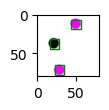

Image: shapes_1.png
Label: shapes_1.json


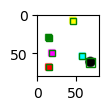

Image: shapes_2.png
Label: shapes_2.json


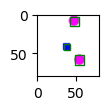

Image: shapes_3.png
Label: shapes_3.json


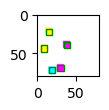

Image: shapes_4.png
Label: shapes_4.json


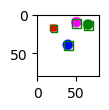

Image: shapes_5.png
Label: shapes_5.json


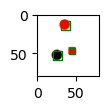

Image: shapes_6.png
Label: shapes_6.json


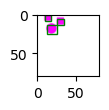

Image: shapes_7.png
Label: shapes_7.json


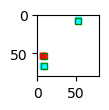

Image: shapes_8.png
Label: shapes_8.json


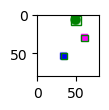

Image: shapes_9.png
Label: shapes_9.json


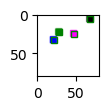

In [8]:
#step3.1: visualization for step 3
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import os

def json_listing(json_data):
    label = []
    for region in json_data:
        label.append([region['x'], region['y'], region['w'], region['h']])
    return label

def bbox_plot(img, boxes):
    # Get image shape
    height, width = img.shape[0], img.shape[1]

    fig, ax = plt.subplots(figsize=(width/100, height/100))
    ax.set_xlim([0, width])
    ax.set_ylim([0, height])
    plt.gca().invert_yaxis()
    ax.imshow(img)

    for box in boxes:
        x, y, w, h = box
        rect = plt.Rectangle(
            (x, y), w, h,
            linewidth=1, edgecolor='g',
            facecolor="none"
        )
        ax.add_patch(rect)

    plt.show()

def bounding_boxes(dataset_dir):
    images_dir = os.path.join(dataset_dir, "images")
    labels_dir = os.path.join(dataset_dir, "labels_json")
    
    img_list = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    lab_list = sorted([f for f in os.listdir(labels_dir) if f.endswith(".json")])
    
    for img_file, lab_file in zip(img_list, lab_list):
        img_path = os.path.join(images_dir, img_file)
        lab_path = os.path.join(labels_dir, lab_file)
        
        img = plt.imread(img_path)
        print("Image:", img_file)
        print("Label:", lab_file)
        with open(lab_path, "r") as jf:
            box_data = json.load(jf)
            boxes = json_listing(box_data)
        
        bbox_plot(img, boxes)

# Now call the function inside the notebook
inline_dataset_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME)
bounding_boxes(inline_dataset_dir)

In [9]:
#step4: Convert Labels to a Single COCO Annotations File
import os
import json
from tqdm import tqdm

# ADDED: Use central IMG_WIDTH and IMG_HEIGHT variables (ensure these are set, e.g., in cell 2 or here)
IMG_WIDTH = 80  # CHANGE: Resolution width
IMG_HEIGHT = 80  # CHANGE: Resolution height

def convert_to_coco(images_dir, labels_dir, output_json):
    coco_data = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "circle", "supercategory": "shape"},
            {"id": 2, "name": "rect", "supercategory": "shape"}
        ]
    }
    annotation_id = 1
    image_id = 1
    image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    for img_file in tqdm(image_files):
        base_name = img_file.replace(".png", "")
        json_file = base_name + ".json"
        json_path = os.path.join(labels_dir, json_file)
        coco_data["images"].append({
            "id": image_id,
            "file_name": img_file,
            "width": IMG_WIDTH,
            "height": IMG_HEIGHT
        })
        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                bbox_data = json.load(f)
            for obj in bbox_data:
                shape_type = obj['object']
                category_id = 1 if shape_type == 'circle' else 2
                x, y, w, h = obj['x'], obj['y'], obj['w'], obj['h']
                coco_data["annotations"].append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "bbox": [x, y, w, h],
                    "segmentation": [],
                    "area": w * h,
                    "iscrowd": 0
                })
                annotation_id += 1
        image_id += 1
    with open(output_json, "w") as f:
        json.dump(coco_data, f)
    print(f"COCO annotations saved to {output_json}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")  # ADDED: Use central config
labels_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "labels_json")  # ADDED: Use central config
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")  # ADDED: Use central config
convert_to_coco(images_dir, labels_dir, output_coco)

100%|████████████████████████████████████████| 10/10 [00:00<00:00, 28206.48it/s]

COCO annotations saved to shapes/shapes_dataset_80x80/coco_annotations.json


In [10]:
#step4.1
import sys
sys.path.insert(0, "/home/maryam_s/Documents/GPU SAM/segment_anything")

import torch
from segment_anything.modeling.image_encoder import ImageEncoderViT
from segment_anything.modeling.prompt_encoder import PromptEncoder
from segment_anything.modeling.mask_decoder import MaskDecoder
from segment_anything.modeling.sam import Sam
from segment_anything import sam_model_registry, SamPredictor

# Use the checkpoint path as usual.
CHECKPOINT_PATH = "/home/maryam_s/Documents/GPU SAM/segment_anything/weights/sam_vit_h_4b8939.pth"
sam_classical = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
sam_classical.to("cpu")

# Extract classical components from the loaded model.
image_encoder = sam_classical.image_encoder
prompt_encoder = sam_classical.prompt_encoder
mask_decoder = sam_classical.mask_decoder

# --- Comment out the quantum-enhanced instantiation ---
# quantum_image_encoder = ImageEncoderViT(
#     img_size=1024,
#     patch_size=16,
#     in_chans=3,
#     embed_dim=768,
#     depth=12,
#     num_heads=12,
#     mlp_ratio=4.0,
#     out_chans=256,
#     qkv_bias=True,
#     use_abs_pos=True,
#     use_rel_pos=False,
#     window_size=0,
#     global_attn_indexes=(),
#     use_quantum=False,          # Currently not activating the quantum branch.
#     n_qubits=8,
#     embedding_type="amplitude"
# )
#
# (Also, comment out any modified prompt_encoder instantiation if applicable.)

# Instantiate SAM using the original classical components.
model = Sam(image_encoder, prompt_encoder, mask_decoder,
            pixel_mean=[123.675, 116.28, 103.53],
            pixel_std=[58.395, 57.12, 57.375])
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs for inference.")
    model = torch.nn.DataParallel(model)
    predictor = SamPredictor(model.module)
else:
    predictor = SamPredictor(model)

print("✅ Classical SAM model loaded on device:", device)
print("Number of transformer blocks:", len(image_encoder.blocks))


Using 3 GPUs for inference.
✅ Classical SAM model loaded on device: cuda
Number of transformer blocks: 32


In [11]:
# Step 5: IOU and Dice Evaluate Segmentation using SAM
print("Starting segmentation evaluation...")
print("Using device:", predictor.model.device)  # Should show cuda:0 or similar

import os
import sys
import json
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn

# --- Evaluation Functions ---

def compute_iou_dice(mask_gt, mask_pred):
    intersection = np.logical_and(mask_gt, mask_pred).sum()
    union = np.logical_or(mask_gt, mask_pred).sum()
    iou = intersection / union if union != 0 else 0
    dice = (2 * intersection) / (mask_gt.sum() + mask_pred.sum()) if (mask_gt.sum() + mask_pred.sum()) != 0 else 0
    return iou, dice

def generate_gt_mask(annotation, image_shape):
    mask = np.zeros(image_shape, dtype=np.uint8)
    obj = annotation['object']
    x = annotation['x']
    y = annotation['y']
    w = annotation['w']
    h = annotation['h']
    if obj == 'rect':
        mask[y:y+h, x:x+w] = 1
    elif obj == 'circle':
        r = w // 2
        cx = x + r
        cy = y + r
        Y, X = np.ogrid[:image_shape[0], :image_shape[1]]
        dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
        mask[dist <= r] = 1
    return mask

def evaluate_segmentation(image_path, annotation_path, predictor):
    start_time = time.time()
    print("Evaluating image:", image_path)
    
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Failed to load image:", image_path)
        return None, None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    with open(annotation_path, 'r') as f:
        annotations = json.load(f)
    
    iou_list = []
    dice_list = []
    for ann in annotations:
        bbox = [ann['x'], ann['y'], ann['x'] + ann['w'], ann['y'] + ann['h']]
        print("Processing annotation:", ann)
        print("Bounding Box:", bbox)
        
        # Set the image in the predictor (this should use GPU if the model is on GPU)
        predictor.set_image(img_rgb)
        masks, scores, _ = predictor.predict(box=np.array(bbox), multimask_output=False)
        
        mask_pred = masks[0] if masks.ndim == 3 else masks
        mask_pred = mask_pred.astype(np.uint8)
        mask_pred = cv2.resize(mask_pred, (w, h), interpolation=cv2.INTER_NEAREST)
        mask_gt = generate_gt_mask(ann, (h, w))
        
        # Debug prints to check mask contents
        print("Predicted mask sum:", mask_pred.sum())
        print("Ground truth mask sum:", mask_gt.sum())
        
        iou, dice = compute_iou_dice(mask_gt, mask_pred)
        print(f"Annotation IoU: {iou:.3f}, Dice: {dice:.3f}")
        iou_list.append(iou)
        dice_list.append(dice)
    
    avg_iou = np.mean(iou_list) if iou_list else 0
    avg_dice = np.mean(dice_list) if dice_list else 0
    elapsed = time.time() - start_time
    print(f"Finished evaluating {image_path} in {elapsed:.2f} seconds.")
    return avg_iou, avg_dice

def evaluate_segmentation_all(predictor, dataset_images, dataset_labels):
    img_files = sorted([f for f in os.listdir(dataset_images) if f.endswith(".png")])
    lab_files = sorted([f for f in os.listdir(dataset_labels) if f.endswith(".json")])
    all_iou = []
    all_dice = []
    total = len(img_files)
    print(f"Found {total} images to evaluate.")
    
    for idx, (img_file, lab_file) in enumerate(zip(img_files, lab_files), start=1):
        print(f"Evaluating image {idx}/{total}: {img_file}")
        image_path = os.path.join(dataset_images, img_file)
        annotation_path = os.path.join(dataset_labels, lab_file)
        iou, dice = evaluate_segmentation(image_path, annotation_path, predictor)
        print(f"{img_file}: IoU={iou:.3f}, Dice={dice:.3f}\n")
        all_iou.append(iou)
        all_dice.append(dice)
    
    avg_iou = np.mean(all_iou) if all_iou else 0
    avg_dice = np.mean(all_dice) if all_dice else 0
    print(f"Average IoU: {avg_iou:.3f}, Average Dice: {avg_dice:.3f}")

# --- (Optional) Print number of transformer blocks in the encoder ---
# (Assuming that "quantum_image_encoder" is your quantum-enhanced encoder used in your SAM model)
#print("Number of transformer blocks in the quantum-enhanced encoder:", len(quantum_image_encoder.blocks))

# --- Update Dataset Paths using dynamic configuration ---
# Make sure these paths match your central configuration
print("Images will be loaded from:", os.path.abspath(DATASET_IMAGES))
print("Labels will be loaded from:", os.path.abspath(DATASET_LABELS))

# --- Run Evaluation ---
evaluate_segmentation_all(predictor, DATASET_IMAGES, DATASET_LABELS)

Starting segmentation evaluation...
Using device: cuda:0
Images will be loaded from: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/images
Labels will be loaded from: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/labels_json
Found 10 images to evaluate.
Evaluating image 1/10: shapes_0.png
Evaluating image: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/images/shapes_0.png
Processing annotation: {'object': 'circle', 'x': 16, 'y': 32, 'w': 12, 'h': 12}
Bounding Box: [16, 32, 28, 44]
Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer block: 2
Processing transformer block: 3
Processing transformer block: 4
Processing transformer block: 5
Processing transformer block: 6
Processing transformer block: 7
Processing transformer block: 8
Processing transformer block: 9
Processing transformer block: 10
Processing transformer block: 11
Pro

Processing transformer block: 15
Processing transformer block: 16
Processing transformer block: 17
Processing transformer block: 18
Processing transformer block: 19
Processing transformer block: 20
Processing transformer block: 21
Processing transformer block: 22
Processing transformer block: 23
Processing transformer block: 24
Processing transformer block: 25
Processing transformer block: 26
Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transformer block: 30
Processing transformer block: 31
Processing transformer block: 32
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 42, 'y': 4, 'w': 8, 'h': 8}
Bounding Box: [42, 4, 50, 12]
Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer bloc

Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer block: 2
Processing transformer block: 3
Processing transformer block: 4
Processing transformer block: 5
Processing transformer block: 6
Processing transformer block: 7
Processing transformer block: 8
Processing transformer block: 9
Processing transformer block: 10
Processing transformer block: 11
Processing transformer block: 12
Processing transformer block: 13
Processing transformer block: 14
Processing transformer block: 15
Processing transformer block: 16
Processing transformer block: 17
Processing transformer block: 18
Processing transformer block: 19
Processing transformer block: 20
Processing transformer block: 21
Processing transformer block: 22
Processing transformer block: 23
Processing transformer block: 24
Processing transformer block: 25
Processing transformer block: 26
Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transfor

Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Finished evaluating /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/images/shapes_3.png in 2.64 seconds.
shapes_3.png: IoU=0.790, Dice=0.883

Evaluating image 5/10: shapes_4.png
Evaluating image: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80/images/shapes_4.png
Processing annotation: {'object': 'circle', 'x': 34, 'y': 34, 'w': 12, 'h': 12}
Bounding Box: [34, 34, 46, 46]
Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer block: 2
Processing transformer block: 3
Processing transformer block: 4
Processing transformer block: 5
Processing transformer block: 6
Processing transformer block: 7
Processing transformer block: 8
Processing transformer block: 9
Processing tran

Processing transformer block: 8
Processing transformer block: 9
Processing transformer block: 10
Processing transformer block: 11
Processing transformer block: 12
Processing transformer block: 13
Processing transformer block: 14
Processing transformer block: 15
Processing transformer block: 16
Processing transformer block: 17
Processing transformer block: 18
Processing transformer block: 19
Processing transformer block: 20
Processing transformer block: 21
Processing transformer block: 22
Processing transformer block: 23
Processing transformer block: 24
Processing transformer block: 25
Processing transformer block: 26
Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transformer block: 30
Processing transformer block: 31
Processing transformer block: 32
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Predicted mask sum: 145
Ground truth mask sum: 113
A

Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transformer block: 30
Processing transformer block: 31
Processing transformer block: 32
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 4, 'y': 63, 'w': 8, 'h': 8}
Bounding Box: [4, 63, 12, 71]
Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer block: 2
Processing transformer block: 3
Processing transformer block: 4
Processing transformer block: 5
Processing transformer block: 6
Processing transformer block: 7
Processing transformer block: 8
Processing transformer block: 9
Processing transformer block: 10
Processing transformer block: 11
Processing transformer block: 12
Processing transformer block: 13
Processing transformer block: 14
Pr

Processing transformer block: 15
Processing transformer block: 16
Processing transformer block: 17
Processing transformer block: 18
Processing transformer block: 19
Processing transformer block: 20
Processing transformer block: 21
Processing transformer block: 22
Processing transformer block: 23
Processing transformer block: 24
Processing transformer block: 25
Processing transformer block: 26
Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transformer block: 30
Processing transformer block: 31
Processing transformer block: 32
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 24, 'y': 19, 'w': 8, 'h': 8}
Bounding Box: [24, 19, 32, 27]
Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer bl

In [12]:
#step6: Convert Binary Masks from SAM -> COCO Polygons
import cv2
import numpy as np

def mask_to_coco_poly(binary_mask):
    """
    Convert a single binary mask (H x W) into COCO polygon format.
    """
    contours, _ = cv2.findContours(binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for contour in contours:
        contour = contour.flatten().tolist()
        if len(contour) >= 6:
            polygons.append(contour)
    return polygons

In [13]:
#step7: Segment with SAM Locally & Update COCO
def segment_with_local_sam(image_dir, input_coco, output_coco):
    with open(input_coco, "r") as f:
        coco_data = json.load(f)
    
    annotations_by_image = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        annotations_by_image.setdefault(img_id, []).append(ann)
    
    for img_info in coco_data["images"]:
        image_id = img_info["id"]
        file_name = img_info["file_name"]
        width = img_info["width"]
        height = img_info["height"]
        
        full_img_path = os.path.join(image_dir, file_name)
        
        image_bgr = cv2.imread(full_img_path)
        if image_bgr is None:
            print(f"❌ Could not load image: {full_img_path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        predictor.set_image(image_rgb)

        if image_id in annotations_by_image:
            for ann in annotations_by_image[image_id]:
                x, y, w, h = ann["bbox"]
                box = np.array([x, y, x + w, y + h])
                
                masks, scores, _ = predictor.predict(box=box, multimask_output=False)

                if masks.ndim == 2:
                    bin_mask = masks
                else:
                    bin_mask = masks[0]
                
                polygons = mask_to_coco_poly(bin_mask)
                ann["segmentation"] = polygons
    
    with open(output_coco, "w") as f:
        json.dump(coco_data, f)
    print(f"✅ COCO file updated with SAM segmentation: {output_coco}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
input_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations_with_masks.json")

segment_with_local_sam(images_dir, input_coco, output_coco)

Number of transformer blocks: 32
Processing transformer block: 1
Processing transformer block: 2
Processing transformer block: 3
Processing transformer block: 4
Processing transformer block: 5
Processing transformer block: 6
Processing transformer block: 7
Processing transformer block: 8
Processing transformer block: 9
Processing transformer block: 10
Processing transformer block: 11
Processing transformer block: 12
Processing transformer block: 13
Processing transformer block: 14
Processing transformer block: 15
Processing transformer block: 16
Processing transformer block: 17
Processing transformer block: 18
Processing transformer block: 19
Processing transformer block: 20
Processing transformer block: 21
Processing transformer block: 22
Processing transformer block: 23
Processing transformer block: 24
Processing transformer block: 25
Processing transformer block: 26
Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transfor

Processing transformer block: 11
Processing transformer block: 12
Processing transformer block: 13
Processing transformer block: 14
Processing transformer block: 15
Processing transformer block: 16
Processing transformer block: 17
Processing transformer block: 18
Processing transformer block: 19
Processing transformer block: 20
Processing transformer block: 21
Processing transformer block: 22
Processing transformer block: 23
Processing transformer block: 24
Processing transformer block: 25
Processing transformer block: 26
Processing transformer block: 27
Processing transformer block: 28
Processing transformer block: 29
Processing transformer block: 30
Processing transformer block: 31
Processing transformer block: 32
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src (image embe

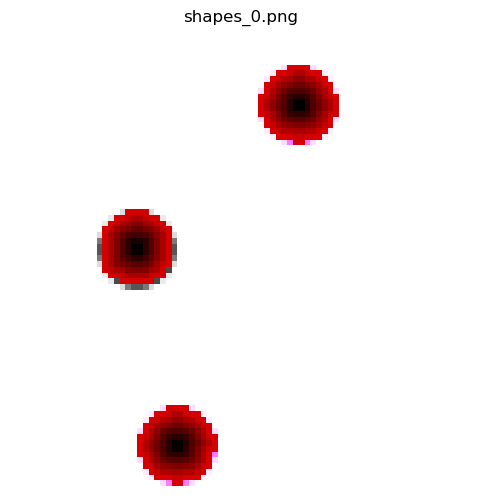

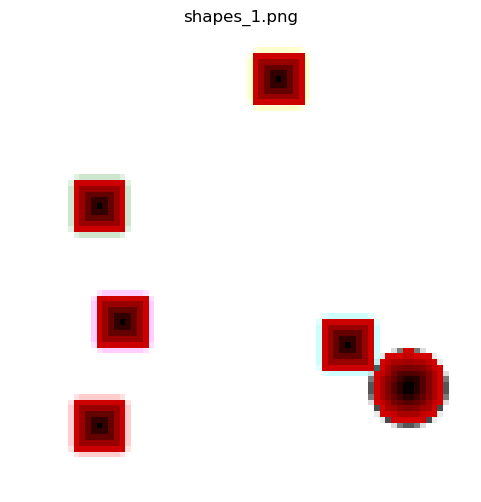

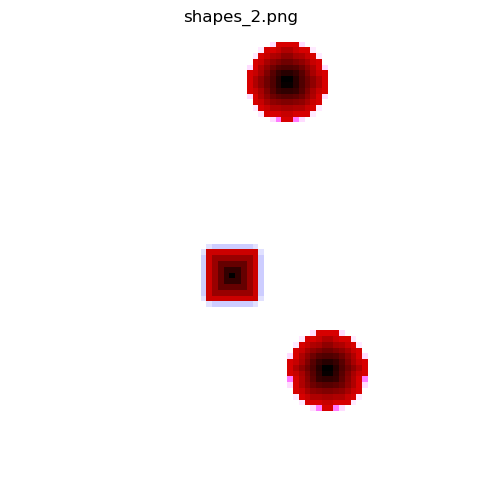

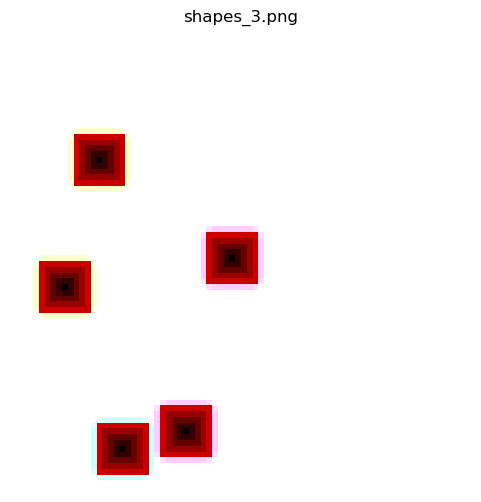

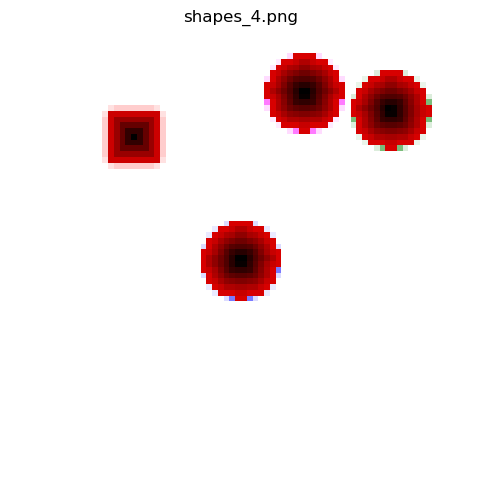

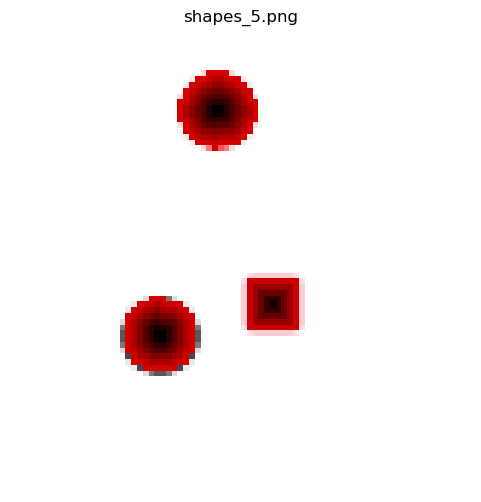

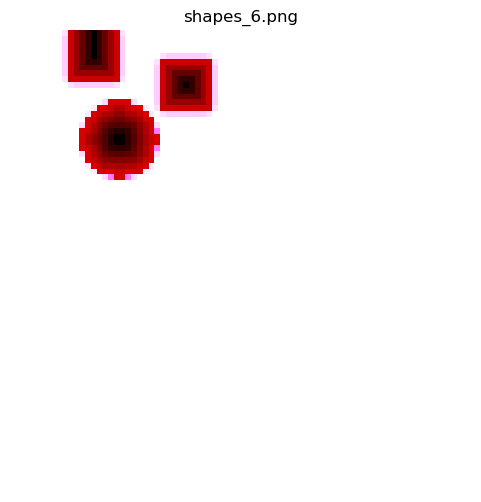

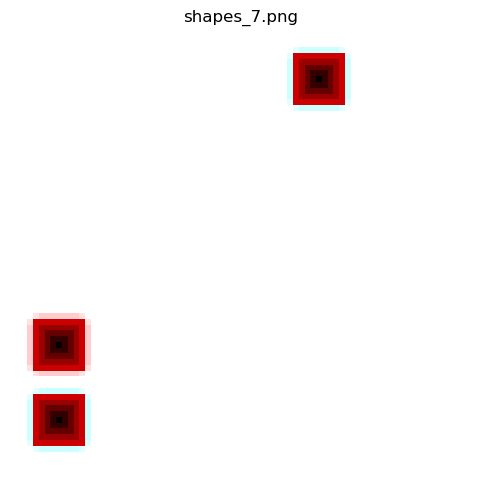

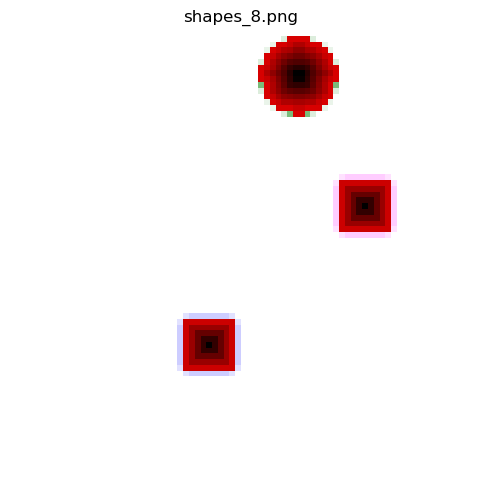

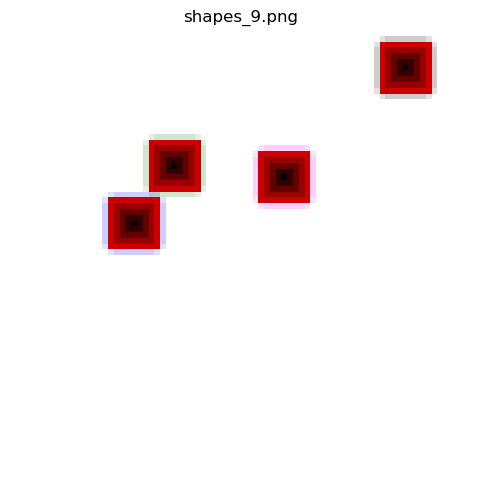

In [14]:
#step8: Visualize the New Segmentation Masks (Optional)
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fill_poly_with_ombre(image, poly, base_color=(255, 0, 0)):
    """
    Fill the polygon defined by `poly` with an ombre effect.
    The effect is computed using a distance transform so that the border 
    is at full intensity and it fades toward the center.
    """
    # Create a binary mask for the polygon.
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    poly_np = np.array(poly).reshape((-1, 2)).astype(np.int32)
    cv2.fillPoly(mask, [poly_np], 255)
    
    # Compute the distance transform: distance of each pixel in the polygon to the nearest edge.
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    
    # Normalize distances to [0,1]
    if np.max(dist) > 0:
        norm = dist / np.max(dist)
    else:
        norm = dist
    
    # Create an intensity map: full intensity at the border (norm=0) and fading towards the center.
    intensity = 1 - norm
    
    # Build an overlay: each channel is the base_color scaled by the intensity.
    overlay = np.zeros_like(image, dtype=np.uint8)
    for i in range(3):
        overlay[:,:,i] = (base_color[i] * intensity).astype(np.uint8)
    
    # Update only the pixels within the polygon.
    result = image.copy()
    result[mask == 255] = overlay[mask == 255]
    return result

def visualize_coco_segmentation_ombre(coco_path, images_dir, base_color=(255, 0, 0)):
    """
    Load the updated COCO annotations, apply the ombre effect to each segmentation polygon,
    and display the resulting image.
    """
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    # Map image_id to its list of annotations.
    ann_dict = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        ann_dict.setdefault(image_id, []).append(ann)
    
    # Process each image.
    for img_info in coco_data['images']:
        image_id = img_info['id']
        file_name = img_info['file_name']
        image_path = os.path.join(images_dir, file_name)
        
        img = cv2.imread(image_path)
        if img is None:
            print("Failed to load:", image_path)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Apply the ombre fill for each segmentation polygon.
        for ann in ann_dict.get(image_id, []):
            for poly in ann.get("segmentation", []):
                if len(poly) < 6:  # Ensure valid polygon
                    continue
                img = fill_poly_with_ombre(img, poly, base_color)
        
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(file_name)
        plt.axis('off')
        plt.show()

# Usage for Step 8:
dataset_dir = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80"
coco_path = os.path.join(dataset_dir, "coco_annotations_with_masks.json")
images_dir = os.path.join(dataset_dir, "images")
visualize_coco_segmentation_ombre(coco_path, images_dir, base_color=(255, 0, 0))

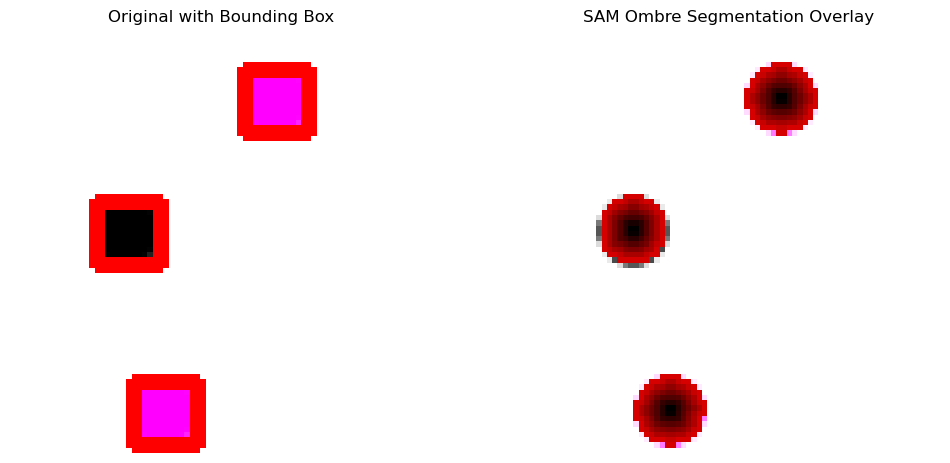

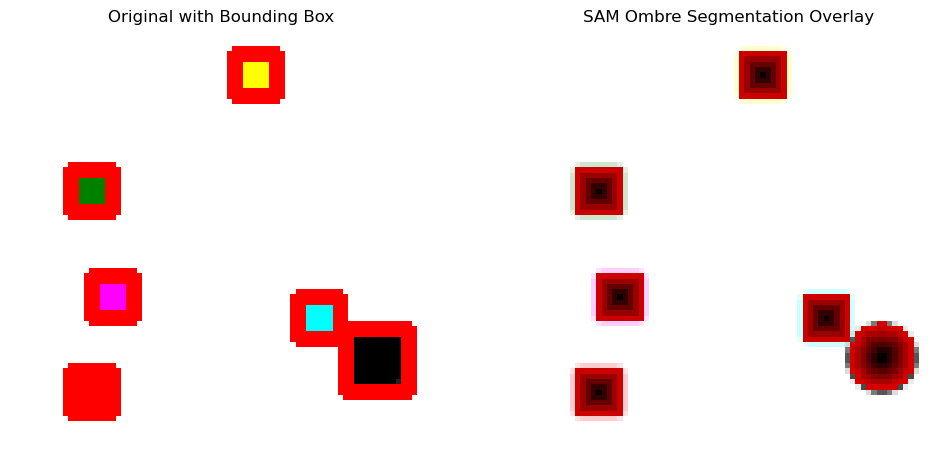

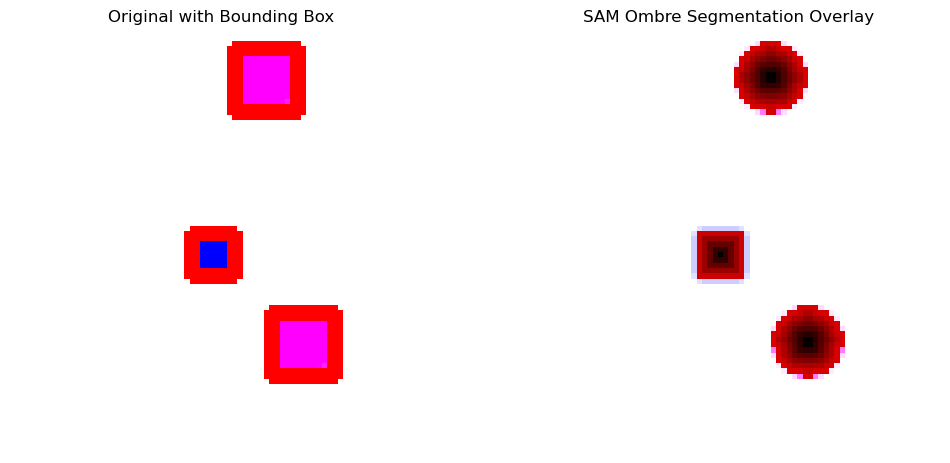

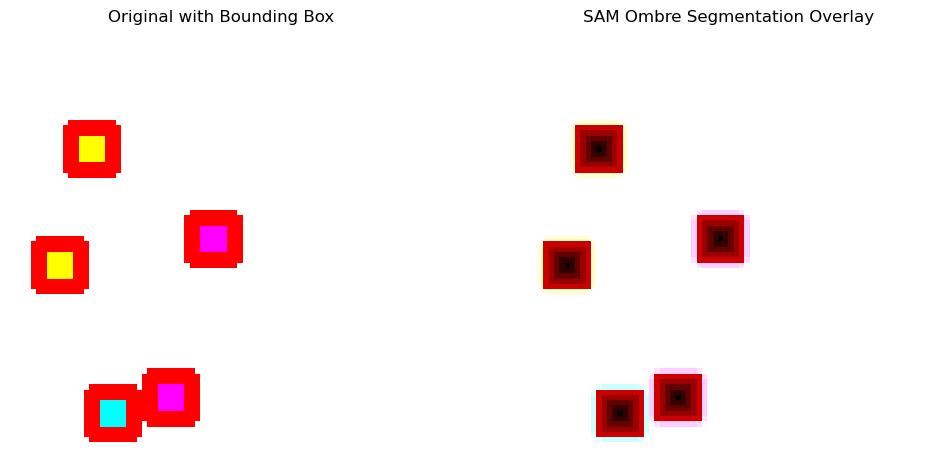

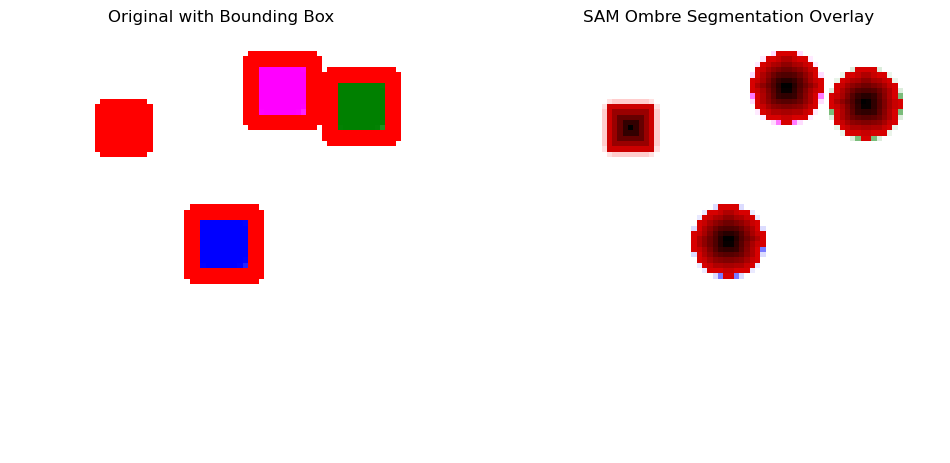

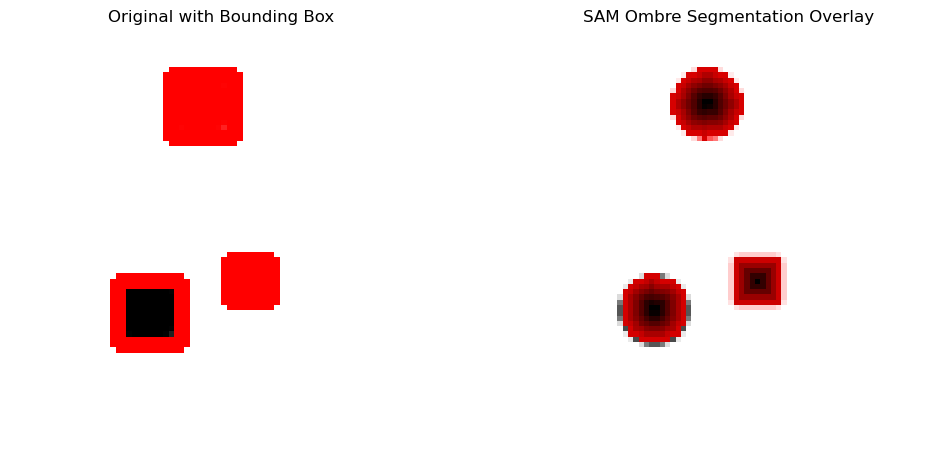

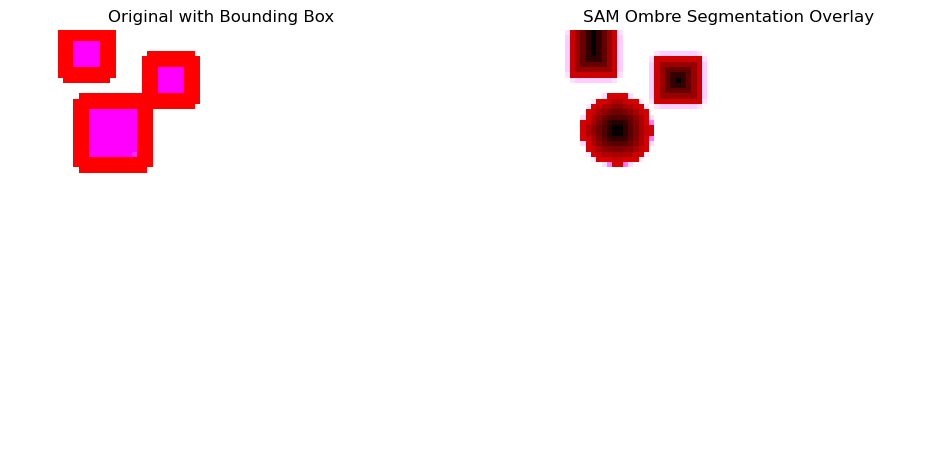

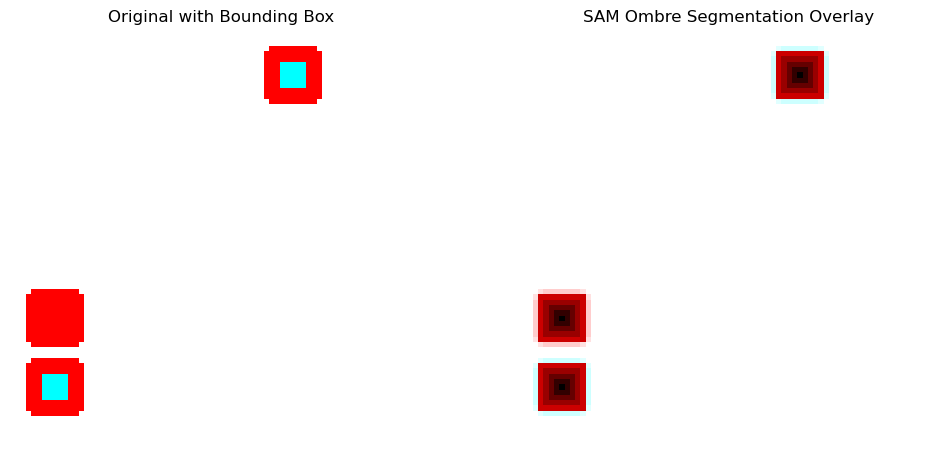

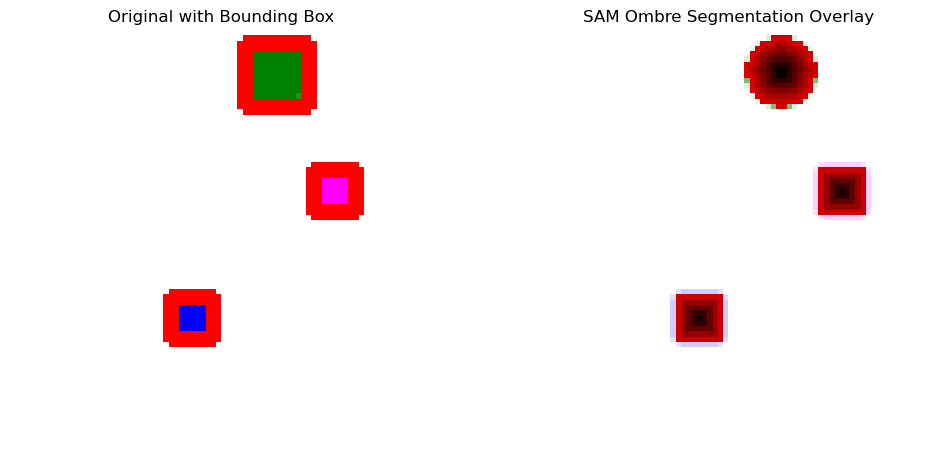

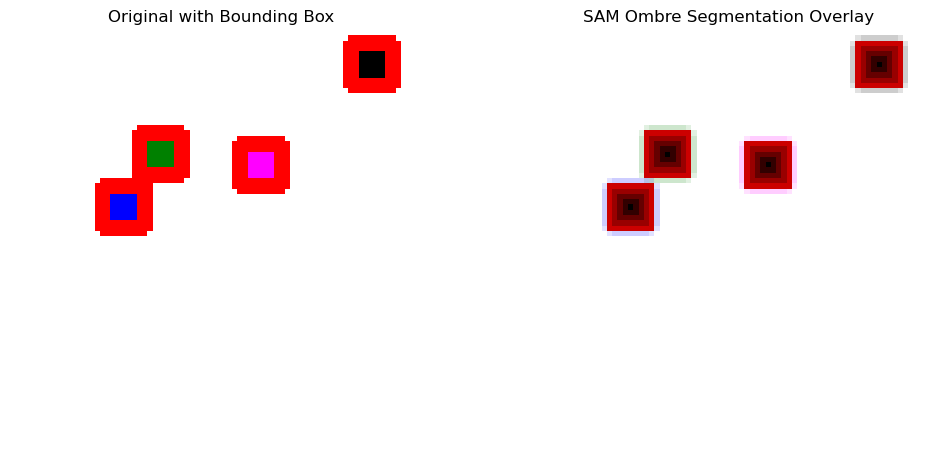

In [15]:
# Step 9: Visualize original img with bbox vs. the New Segmentation Masks 
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_comparison_coco_ombre(coco_path, images_dir, base_color=(255, 0, 0)):
    """
    Displays a side-by-side comparison for each image:
      - Left: Original image with bounding boxes.
      - Right: Image with segmentation regions filled using an ombre effect.
    """
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    # Map image_id to its annotations.
    ann_dict = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        ann_dict.setdefault(image_id, []).append(ann)
    
    # Process each image.
    for img_info in coco_data['images']:
        image_id = img_info['id']
        file_name = img_info['file_name']
        image_path = os.path.join(images_dir, file_name)
        
        img = cv2.imread(image_path)
        if img is None:
            print("Failed to load:", image_path)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Create a copy for drawing bounding boxes.
        img_bbox = img.copy()
        anns = ann_dict.get(image_id, [])
        for ann in anns:
            bbox = ann.get("bbox", None)
            if bbox is not None:
                # bbox format: [x, y, w, h]
                x, y, w, h = bbox
                cv2.rectangle(img_bbox, (int(x), int(y)), (int(x+w), int(y+h)), color=(255, 0, 0), thickness=2)
        
        # Create a copy for the ombre segmentation overlay.
        img_ombre = img.copy()
        for ann in anns:
            for poly in ann.get("segmentation", []):
                if len(poly) < 6:
                    continue
                img_ombre = fill_poly_with_ombre(img_ombre, poly, base_color)
        
        # Display side-by-side comparison.
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(img_bbox)
        axs[0].set_title("Original with Bounding Box")
        axs[0].axis('off')
        
        axs[1].imshow(img_ombre)
        axs[1].set_title("SAM Ombre Segmentation Overlay")
        axs[1].axis('off')
        
        plt.show()

# Usage for Step 9:
visualize_comparison_coco_ombre(coco_path, images_dir, base_color=(255, 0, 0))